<a href="https://colab.research.google.com/github/PandeyChhaya/6CS012-AI-ML/blob/main/Worksheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - Worksheet 3
## MCP Neurons & Perceptron Learning Algorithm

## Task 1: MCP Neurons

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = [1 if s >= T else 0 for s in sums]
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2
result = MCP_Neurons_AND(X1, X2, T)
print(f'AND gate output: {result}')


def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = [1 if s >= T else 0 for s in sums]
    return state_neuron

T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f'OR gate output: {result_or}')

AND gate output: [0, 0, 0, 1]
OR gate output: [0, 1, 1, 1]


### Question 1: Limitations of MCP Neurons

1. **No learning** — thresholds must be hand-crafted manually; the model cannot learn from data.
2. **Binary inputs only** — cannot handle real-valued or continuous inputs.
3. **Fixed weights** — all inputs are treated equally (weight = 1); no notion of importance.
4. **No bias** — the threshold is fixed and not learnable.
5. **Cannot solve XOR** — limited to linearly separable problems.
6. **Inhibitory inputs are all-or-nothing** — any inhibitory input forces output to 0 regardless of excitatory inputs.

### Question 2: Can MCP solve XOR?

XOR cannot be solved by a single MCP neuron because XOR is **not linearly separable**. However, using **two MCP neurons in combination** we can simulate it:

- XOR(x1, x2) = OR(x1,x2) AND NOT AND(x1,x2)
- Step 1: compute OR (T=1) → out1
- Step 2: compute NAND (T=1, negate AND) → out2
- Step 3: AND(out1, out2) → XOR result

So XOR **requires a network of MCP neurons**, not a single one.

## Task 2: Perceptron — 0 vs 1 Classification

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd



df_0_1 = pd.read_csv('/content/drive/MyDrive/mnist_0_and_1.csv')
X = df_0_1.drop(columns=['label']).values
y = df_0_1['label'].values
print('Feature matrix shape:', X.shape)
print('Label vector shape:  ', y.shape)

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


**Q1 — Shape of X:** `(n_samples, 784)` — each row is one image flattened from 28×28 pixels into 784 features.

**Q2 — Shape of y:** `(n_samples,)` — one label (0 or 1) per image.

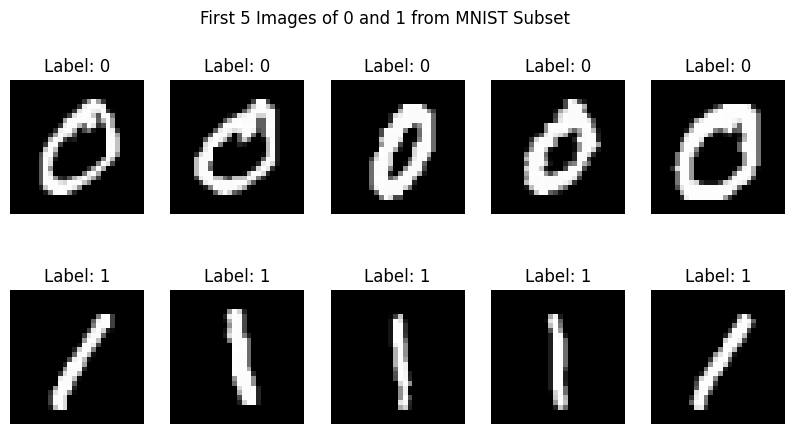

In [4]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title('Label: 0'); axes[0, i].axis('off')
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Label: 1'); axes[1, i].axis('off')
plt.suptitle('First 5 Images of 0 and 1 from MNIST Subset')
plt.show()

In [6]:

weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

**Q3 — What does weights represent?** A vector of 784 values (one per pixel) controlling how much each pixel contributes to the final decision.

**Q4 — Why initialize to zero?** It's a neutral starting point — no pixel is preferred over another. The algorithm then updates weights purely based on errors. A downside is that all neurons in a layer learn identically in symmetric networks, but for a single perceptron it works fine.

In [7]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all  = np.where(predictions >= 0, 1, 0)  # step function
    return y_pred_all


def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        converged = True
        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0
            if y_pred != y[i]:
                error     = y[i] - y_pred
                weights  += learning_rate * error * X[i]
                bias     += learning_rate * error
                converged = False
        if converged:
            print(f'Converged at epoch {epoch}')
            break
    # final accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy   = np.mean(y_pred_all == y)
    return weights, bias, accuracy

**Q5 — Purpose of `np.dot(X[i], weights) + bias`:** Computes the weighted sum z = Σ(wᵢxᵢ) + b — this is the raw score before the activation function.

**Q6 — What happens when prediction is wrong?** `error = y - ŷ` is ±1. Weights shift by `η × error × x`, pushing the boundary toward correct classification. Bias shifts by `η × error`.

**Q7 — Why is final accuracy important?** It tells us how well the perceptron learned. For 0 vs 1 (linearly separable), we expect ~99-100% since the perceptron convergence theorem guarantees convergence on linearly separable data.

In [8]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print('The Final Accuracy is:', accuracy)

Converged at epoch 12
The Final Accuracy is: 1.0


In [9]:
# Visualize misclassified images
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)
final_accuracy = np.mean(y_pred == y)
print(f'Final Accuracy: {final_accuracy:.4f}')

misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Pred:{y_pred[idx]}, True:{y[idx]}')
        ax.axis('off')
    plt.suptitle('Misclassified Images')
    plt.show()
else:
    print('All images were correctly classified!')

Final Accuracy: 1.0000
All images were correctly classified!


**Q8 — What does `misclassified_idx` store?** Indices where `y_pred != y`. Used to index into X and y to display the wrongly predicted images with their true and predicted labels.

**Q9 — Interpretation of 'All correctly classified'?** It means the perceptron found a perfect linear decision boundary separating 0s and 1s — expected since these two digits are visually very different and linearly separable in pixel space.

## Task 3: Perceptron — 3 vs 5 Classification

In [14]:
df_3_5 = pd.read_csv('/content/drive/MyDrive/mnist_3_and_5.csv')  # update path
X2 = df_3_5.drop(columns=['label']).values
y2 = df_3_5['label'].values

# Remap labels: 3->0, 5->1 for binary classification
y2_bin = np.where(y2 == 3, 0, 1)

print('Feature matrix shape:', X2.shape)
print('Label vector shape:  ', y2.shape)


Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)


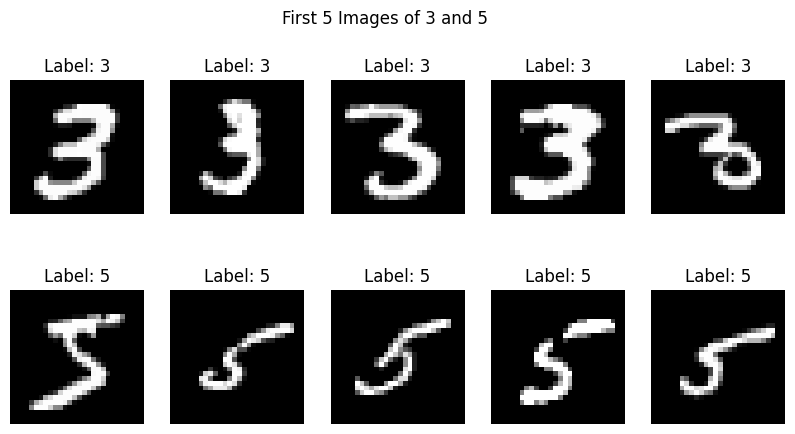

In [15]:
# Visualize
images_3 = X2[y2 == 3]
images_5 = X2[y2 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title('Label: 3'); axes[0, i].axis('off')
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Label: 5'); axes[1, i].axis('off')
plt.suptitle('First 5 Images of 3 and 5')
plt.show()

In [16]:
# Train perceptron on 3 vs 5
weights2 = np.zeros(X2.shape[1])
bias2    = 0

weights2, bias2, accuracy2 = train_perceptron(X2, y2_bin, weights2, bias2, learning_rate=0.1, epochs=100)
print('Final Accuracy (3 vs 5):', accuracy2)

Final Accuracy (3 vs 5): 0.986866107260124


Final Accuracy: 0.9869


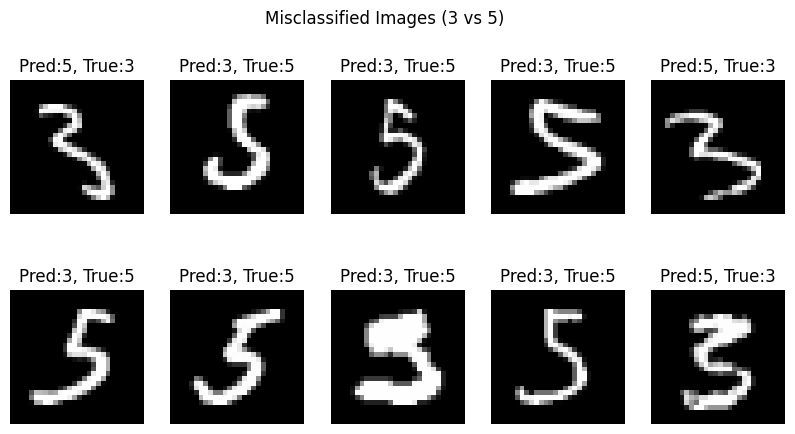

In [17]:
# Misclassified images for 3 vs 5
predictions2 = np.dot(X2, weights2) + bias2
y_pred2      = np.where(predictions2 >= 0, 1, 0)
final_acc2   = np.mean(y_pred2 == y2_bin)
print(f'Final Accuracy: {final_acc2:.4f}')

misclassified2 = np.where(y_pred2 != y2_bin)[0]
if len(misclassified2) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified2[:10]):
        ax.imshow(X2[idx].reshape(28, 28), cmap='gray')
        true_label = y2[idx]  # original label (3 or 5)
        pred_label = 3 if y_pred2[idx] == 0 else 5
        ax.set_title(f'Pred:{pred_label}, True:{true_label}')
        ax.axis('off')
    plt.suptitle('Misclassified Images (3 vs 5)')
    plt.show()
else:
    print('All images were correctly classified!')

### Conclusion — 3 vs 5 Classification

The digits 3 and 5 are **visually similar** (both have curved strokes and similar pixel distributions), making them harder to separate than 0 vs 1. The perceptron will likely achieve lower accuracy (~85–95%) with some misclassifications. The misclassified images are typically ambiguous or poorly written digits where the linear decision boundary cannot correctly separate them. This demonstrates the **core limitation of the perceptron** — it can only learn a linear decision boundary, and when classes are not perfectly linearly separable (as with 3 vs 5), some errors are unavoidable.